# 06 — Hyperparameter Tuning

**Joint notebook**, same CV harness and folds as notebook 05. Tune with `RandomizedSearchCV` (`scoring="average_precision"`, `random_state=RANDOM_STATE`), about 30-50 iterations.

| Owner | Model | Tuning focus |
| --- | --- | --- |
| Meegasthanna | Logistic Regression | `C`, `penalty`, `class_weight` |
| Bandara | XGBoost / LightGBM | `n_estimators`, `max_depth`, `learning_rate`, `scale_pos_weight` |
| Seneviratne | Random Forest | `n_estimators`, `max_depth`, `min_samples_leaf`, `class_weight` |
| Umer | SVM (RBF) | `C`, `gamma`, `class_weight` |

Umer also owns the SMOTE-vs-class-weights ablation and decision-threshold tuning (cross-cutting, applies to whichever model ends up selected).

**Output:** the results table from 05 extended with tuned rows (baseline vs tuned comparison).

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [2]:
import json

import numpy as np
import pandas as pd
from scipy.stats import randint, uniform, loguniform

from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
import xgboost as xgb

from src.config import RANDOM_STATE, PROCESSED_DATA_DIR
from src.pipeline import build_preprocessing_pipeline
from src.evaluate import evaluate_cv, METRIC_NAMES

## Load the same train split and CV folds as notebook 05

Same `StratifiedGroupKFold` configuration (same `random_state`, same `n_splits`) as notebook 05, so baseline and tuned results are comparable.

In [3]:
train_df = pd.read_parquet(PROCESSED_DATA_DIR / "train.parquet")

with open(PROCESSED_DATA_DIR / "eligible_features.json") as f:
    eligible_features = json.load(f)

binary_cols = ["grip_lost"]
continuous_cols = [c for c in eligible_features if c not in binary_cols]

X_train = train_df[eligible_features]
y_train = train_df["Robot_ProtectiveStop"]
groups = train_df["cycle"]

# Same fold configuration as notebook 05, so baseline and tuned results are comparable
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X_train.shape, y_train.mean()

((5468, 16), 0.03108997805413314)

## Results table (baseline vs tuned)

The baseline rows are copied from notebook 05's output (pinned values in the same `evaluate_cv()` format; notebook 06 does not re-run the baselines), and a tuned row is added for each model below.

In [4]:
result_columns = ["model", "stage"] + [f"{m}_mean" for m in METRIC_NAMES] + [f"{m}_std" for m in METRIC_NAMES] + ["best_params"]
results = pd.DataFrame(columns=result_columns)

def add_result(model_name, stage, scores, best_params=None):
    row = {"model": model_name, "stage": stage, "best_params": best_params, **scores}
    results.loc[len(results)] = row

# Seed with the baseline rows from notebook 05 (pinned values, same evaluate_cv() output format --
# notebook 06 doesn't re-run the baselines itself, so these should be refreshed if 05 is re-run with changes)
add_result("Dummy", "baseline", {
    "pr_auc_mean": 0.031932, "pr_auc_std": 0.005905,
    "recall_mean": 0.037326, "recall_std": 0.021369,
    "precision_mean": 0.036955, "precision_std": 0.023863,
    "f1_mean": 0.036773, "f1_std": 0.022340,
    "balanced_accuracy_mean": 0.504153, "balanced_accuracy_std": 0.010333,
    "roc_auc_mean": 0.504153, "roc_auc_std": 0.010333,
})
add_result("Logistic Regression", "baseline", {
    "pr_auc_mean": 0.111114, "pr_auc_std": 0.028067,
    "recall_mean": 0.671541, "recall_std": 0.094414,
    "precision_mean": 0.065405, "precision_std": 0.014887,
    "f1_mean": 0.118519, "f1_std": 0.024752,
    "balanced_accuracy_mean": 0.681313, "balanced_accuracy_std": 0.037009,
    "roc_auc_mean": 0.736851, "roc_auc_std": 0.068731,
})
add_result("XGBoost", "baseline", {
    "pr_auc_mean": 0.418357, "pr_auc_std": 0.037234,
    "recall_mean": 0.307251, "recall_std": 0.133273,
    "precision_mean": 0.551728, "precision_std": 0.131464,
    "f1_mean": 0.361558, "f1_std": 0.133408,
    "balanced_accuracy_mean": 0.648908, "balanced_accuracy_std": 0.064885,
    "roc_auc_mean": 0.911487, "roc_auc_std": 0.053311,
})
add_result("Random Forest", "baseline", {
    "pr_auc_mean": 0.428161, "pr_auc_std": 0.065739,
    "recall_mean": 0.161404, "recall_std": 0.116410,
    "precision_mean": 0.478959, "precision_std": 0.254741,
    "f1_mean": 0.230981, "f1_std": 0.148579,
    "balanced_accuracy_mean": 0.579038, "balanced_accuracy_std": 0.057255,
    "roc_auc_mean": 0.914904, "roc_auc_std": 0.055305,
})
add_result("SVM (RBF)", "baseline", {
    "pr_auc_mean": 0.254491, "pr_auc_std": 0.038116,
    "recall_mean": 0.732430, "recall_std": 0.149087,
    "precision_mean": 0.134044, "precision_std": 0.039397,
    "f1_mean": 0.223520, "f1_std": 0.058394,
    "balanced_accuracy_mean": 0.788816, "balanced_accuracy_std": 0.063932,
    "roc_auc_mean": 0.840530, "roc_auc_std": 0.074577,
})

results

,model,stage,pr_auc_mean,recall_mean,precision_mean,f1_mean,balanced_accuracy_mean,roc_auc_mean,pr_auc_std,recall_std,precision_std,f1_std,balanced_accuracy_std,roc_auc_std,best_params
0,Dummy,baseline,0.031932,0.037326,0.036955,0.036773,0.504153,0.504153,0.005905,0.021369,0.023863,0.022340,0.010333,0.010333,None
1,Logistic Regression,baseline,0.111114,0.671541,0.065405,0.118519,0.681313,0.736851,0.028067,0.094414,0.014887,0.024752,0.037009,0.068731,None
2,XGBoost,baseline,0.418357,0.307251,0.551728,0.361558,0.648908,0.911487,0.037234,0.133273,0.131464,0.133408,0.064885,0.053311,None
3,Random Forest,baseline,0.428161,0.161404,0.478959,0.230981,0.579038,0.914904,0.065739,0.116410,0.254741,0.148579,0.057255,0.055305,None
4,SVM (RBF),baseline,0.254491,0.732430,0.134044,0.223520,0.788816,0.840530,0.038116,0.149087,0.039397,0.058394,0.063932,0.074577,None


## Logistic Regression tuning — Meegasthanna

In [5]:
logreg_pipeline = Pipeline([
    ("preprocessing", build_preprocessing_pipeline(continuous_cols, binary_cols)),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, solver="liblinear")),
])

logreg_param_dist = {
    "classifier__C": loguniform(1e-4, 1e2),
    "classifier__penalty": ["l1", "l2"],
    "classifier__class_weight": ["balanced", None, {0: 1, 1: 10}, {0: 1, 1: 25}, {0: 1, 1: 32}]
}

logreg_search = RandomizedSearchCV(
    estimator=logreg_pipeline,
    param_distributions=logreg_param_dist,
    n_iter=35,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

logreg_search.fit(X_train, y_train, groups=groups)
print(f"Best CV PR-AUC Score: {logreg_search.best_score_:.4f}")
print("Best Hyperparameters:", logreg_search.best_params_)

# Evaluate tuned pipeline across the standard 5-fold CV harness
logreg_tuned_scores = evaluate_cv(logreg_search.best_estimator_, X_train, y_train, groups)
add_result("Logistic Regression", "tuned", logreg_tuned_scores, logreg_search.best_params_)

results

Best CV PR-AUC Score: 0.1647
Best Hyperparameters: {'classifier__C': 0.04994877024461302, 'classifier__class_weight': None, 'classifier__penalty': 'l2'}


,model,stage,pr_auc_mean,recall_mean,precision_mean,f1_mean,balanced_accuracy_mean,roc_auc_mean,pr_auc_std,recall_std,precision_std,f1_std,balanced_accuracy_std,roc_auc_std,best_params
0,Dummy,baseline,0.031932,0.037326,0.036955,0.036773,0.504153,0.504153,0.005905,0.021369,0.023863,0.022340,0.010333,0.010333,None
1,Logistic Regression,baseline,0.111114,0.671541,0.065405,0.118519,0.681313,0.736851,0.028067,0.094414,0.014887,0.024752,0.037009,0.068731,None
2,XGBoost,baseline,0.418357,0.307251,0.551728,0.361558,0.648908,0.911487,0.037234,0.133273,0.131464,0.133408,0.064885,0.053311,None
3,Random Forest,baseline,0.428161,0.161404,0.478959,0.230981,0.579038,0.914904,0.065739,0.116410,0.254741,0.148579,0.057255,0.055305,None
4,SVM (RBF),baseline,0.254491,0.732430,0.134044,0.223520,0.788816,0.840530,0.038116,0.149087,0.039397,0.058394,0.063932,0.074577,None
5,Logistic Regression,tuned,0.164665,0.000000,0.000000,0.000000,0.500000,0.765985,0.022747,0.000000,0.000000,0.000000,0.000000,0.054951,"{'classifier__C': 0.04994877024461302, 'classi..."


## XGBoost / LightGBM tuning — Bandara

In [6]:
xgb_param_dist = {
    "classifier__n_estimators": randint(100, 500),
    "classifier__max_depth": randint(3, 10),
    "classifier__learning_rate": uniform(0.01, 0.29),
    "classifier__scale_pos_weight": uniform(1, 30),
}

xgb_search_pipeline = Pipeline([
    ("preprocessing", build_preprocessing_pipeline(continuous_cols, binary_cols)),
    ("classifier", xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric="aucpr")),
])

xgb_search = RandomizedSearchCV(
    xgb_search_pipeline, xgb_param_dist, n_iter=40,
    scoring="average_precision", cv=cv, random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_search.fit(X_train, y_train, groups=groups)

print("Best CV PR-AUC (search):", xgb_search.best_score_)
print("Best params:", xgb_search.best_params_)

# Re-run through evaluate_cv with the best params for the full metric set (mean+std),
# so this row is directly comparable to the baseline row's format.
best_xgb_params = {k.replace("classifier__", ""): v for k, v in xgb_search.best_params_.items()}
xgb_tuned_pipeline = Pipeline([
    ("preprocessing", build_preprocessing_pipeline(continuous_cols, binary_cols)),
    ("classifier", xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric="aucpr", **best_xgb_params)),
])
xgb_tuned_scores = evaluate_cv(xgb_tuned_pipeline, X_train, y_train, groups)
add_result("XGBoost", "tuned", xgb_tuned_scores, best_params=best_xgb_params)
results

Best CV PR-AUC (search): 0.4732048121862384
Best params: {'classifier__learning_rate': 0.04540550686319527, 'classifier__max_depth': 3, 'classifier__n_estimators': 330, 'classifier__scale_pos_weight': 28.204853246372622}


,model,stage,pr_auc_mean,recall_mean,precision_mean,f1_mean,balanced_accuracy_mean,roc_auc_mean,pr_auc_std,recall_std,precision_std,f1_std,balanced_accuracy_std,roc_auc_std,best_params
0,Dummy,baseline,0.031932,0.037326,0.036955,0.036773,0.504153,0.504153,0.005905,0.021369,0.023863,0.022340,0.010333,0.010333,None
1,Logistic Regression,baseline,0.111114,0.671541,0.065405,0.118519,0.681313,0.736851,0.028067,0.094414,0.014887,0.024752,0.037009,0.068731,None
2,XGBoost,baseline,0.418357,0.307251,0.551728,0.361558,0.648908,0.911487,0.037234,0.133273,0.131464,0.133408,0.064885,0.053311,None
3,Random Forest,baseline,0.428161,0.161404,0.478959,0.230981,0.579038,0.914904,0.065739,0.116410,0.254741,0.148579,0.057255,0.055305,None
4,SVM (RBF),baseline,0.254491,0.732430,0.134044,0.223520,0.788816,0.840530,0.038116,0.149087,0.039397,0.058394,0.063932,0.074577,None
5,Logistic Regression,tuned,0.164665,0.000000,0.000000,0.000000,0.500000,0.765985,0.022747,0.000000,0.000000,0.000000,0.000000,0.054951,"{'classifier__C': 0.04994877024461302, 'classi..."
6,XGBoost,tuned,0.473205,0.689142,0.441291,0.512834,0.828957,0.923935,0.074298,0.159186,0.093766,0.040011,0.072297,0.048781,"{'learning_rate': 0.04540550686319527, 'max_de..."


## Random Forest tuning — Seneviratne

In [7]:
rf_param_dist = {
    "classifier__n_estimators": randint(100, 500),
    "classifier__max_depth": randint(3, 20),
    "classifier__min_samples_leaf": randint(1, 20),
    "classifier__class_weight": ["balanced", "balanced_subsample"],
}

rf_search_pipeline = Pipeline([
    ("preprocessing", build_preprocessing_pipeline(continuous_cols, binary_cols)),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE)),
])

rf_search = RandomizedSearchCV(
    rf_search_pipeline, rf_param_dist, n_iter=40,
    scoring="average_precision", cv=cv, random_state=RANDOM_STATE, n_jobs=-1,
)
rf_search.fit(X_train, y_train, groups=groups)

print("Best CV PR-AUC (search):", rf_search.best_score_)
print("Best params:", rf_search.best_params_)

best_rf_params = {k.replace("classifier__", ""): v for k, v in rf_search.best_params_.items()}
rf_tuned_pipeline = Pipeline([
    ("preprocessing", build_preprocessing_pipeline(continuous_cols, binary_cols)),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, **best_rf_params)),
])
rf_tuned_scores = evaluate_cv(rf_tuned_pipeline, X_train, y_train, groups)
add_result("Random Forest", "tuned", rf_tuned_scores, best_params=best_rf_params)
results

Best CV PR-AUC (search): 0.4386408601865659
Best params: {'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': 15, 'classifier__min_samples_leaf': 7, 'classifier__n_estimators': 286}


,model,stage,pr_auc_mean,recall_mean,precision_mean,f1_mean,balanced_accuracy_mean,roc_auc_mean,pr_auc_std,recall_std,precision_std,f1_std,balanced_accuracy_std,roc_auc_std,best_params
0,Dummy,baseline,0.031932,0.037326,0.036955,0.036773,0.504153,0.504153,0.005905,0.021369,0.023863,0.022340,0.010333,0.010333,None
1,Logistic Regression,baseline,0.111114,0.671541,0.065405,0.118519,0.681313,0.736851,0.028067,0.094414,0.014887,0.024752,0.037009,0.068731,None
2,XGBoost,baseline,0.418357,0.307251,0.551728,0.361558,0.648908,0.911487,0.037234,0.133273,0.131464,0.133408,0.064885,0.053311,None
3,Random Forest,baseline,0.428161,0.161404,0.478959,0.230981,0.579038,0.914904,0.065739,0.116410,0.254741,0.148579,0.057255,0.055305,None
4,SVM (RBF),baseline,0.254491,0.732430,0.134044,0.223520,0.788816,0.840530,0.038116,0.149087,0.039397,0.058394,0.063932,0.074577,None
5,Logistic Regression,tuned,0.164665,0.000000,0.000000,0.000000,0.500000,0.765985,0.022747,0.000000,0.000000,0.000000,0.000000,0.054951,"{'classifier__C': 0.04994877024461302, 'classi..."
6,XGBoost,tuned,0.473205,0.689142,0.441291,0.512834,0.828957,0.923935,0.074298,0.159186,0.093766,0.040011,0.072297,0.048781,"{'learning_rate': 0.04540550686319527, 'max_de..."
7,Random Forest,tuned,0.438641,0.498633,0.412888,0.431612,0.737704,0.938454,0.110591,0.159130,0.087040,0.081180,0.075512,0.043814,"{'class_weight': 'balanced_subsample', 'max_de..."


## SVM (RBF) tuning — Umer

In [8]:
svm_param_dist = {
    "classifier__C": loguniform(1e-2, 1e2),
    "classifier__gamma": loguniform(1e-4, 1e0),
    "classifier__class_weight": ["balanced", None],
}

svm_search_pipeline = Pipeline([
    ("preprocessing", build_preprocessing_pipeline(continuous_cols, binary_cols)),
    ("classifier", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
])

svm_search = RandomizedSearchCV(
    svm_search_pipeline, svm_param_dist, n_iter=40,
    scoring="average_precision", cv=cv, random_state=RANDOM_STATE, n_jobs=-1,  # speed only: search results don't depend on n_jobs; SVC(probability=True) is slow
)
svm_search.fit(X_train, y_train, groups=groups)
print("Best CV PR-AUC (search):", svm_search.best_score_)
print("Best params:", svm_search.best_params_)

# Re-run through evaluate_cv with the best params for the full metric set (mean+std)
best_svm_params = {k.replace("classifier__", ""): v for k, v in svm_search.best_params_.items()}
svm_tuned_pipeline = Pipeline([
    ("preprocessing", build_preprocessing_pipeline(continuous_cols, binary_cols)),
    ("classifier", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE, **best_svm_params)),
])
svm_tuned_scores = evaluate_cv(svm_tuned_pipeline, X_train, y_train, groups)
add_result("SVM (RBF)", "tuned", svm_tuned_scores, best_svm_params)
results

Best CV PR-AUC (search): 0.3879636168043847
Best params: {'classifier__C': 8.241925264876453, 'classifier__class_weight': 'balanced', 'classifier__gamma': 0.02653627132902631}


,model,stage,pr_auc_mean,recall_mean,precision_mean,f1_mean,balanced_accuracy_mean,roc_auc_mean,pr_auc_std,recall_std,precision_std,f1_std,balanced_accuracy_std,roc_auc_std,best_params
0,Dummy,baseline,0.031932,0.037326,0.036955,0.036773,0.504153,0.504153,0.005905,0.021369,0.023863,0.022340,0.010333,0.010333,None
1,Logistic Regression,baseline,0.111114,0.671541,0.065405,0.118519,0.681313,0.736851,0.028067,0.094414,0.014887,0.024752,0.037009,0.068731,None
2,XGBoost,baseline,0.418357,0.307251,0.551728,0.361558,0.648908,0.911487,0.037234,0.133273,0.131464,0.133408,0.064885,0.053311,None
3,Random Forest,baseline,0.428161,0.161404,0.478959,0.230981,0.579038,0.914904,0.065739,0.116410,0.254741,0.148579,0.057255,0.055305,None
4,SVM (RBF),baseline,0.254491,0.732430,0.134044,0.223520,0.788816,0.840530,0.038116,0.149087,0.039397,0.058394,0.063932,0.074577,None
5,Logistic Regression,tuned,0.164665,0.000000,0.000000,0.000000,0.500000,0.765985,0.022747,0.000000,0.000000,0.000000,0.000000,0.054951,"{'classifier__C': 0.04994877024461302, 'classi..."
6,XGBoost,tuned,0.473205,0.689142,0.441291,0.512834,0.828957,0.923935,0.074298,0.159186,0.093766,0.040011,0.072297,0.048781,"{'learning_rate': 0.04540550686319527, 'max_de..."
7,Random Forest,tuned,0.438641,0.498633,0.412888,0.431612,0.737704,0.938454,0.110591,0.159130,0.087040,0.081180,0.075512,0.043814,"{'class_weight': 'balanced_subsample', 'max_de..."
8,SVM (RBF),tuned,0.388141,0.736019,0.237782,0.354221,0.829421,0.874913,0.062567,0.140009,0.050399,0.061528,0.063128,0.063234,"{'C': 8.241925264876453, 'class_weight': 'bala..."


## SMOTE vs class weights — Umer

For the leading model, compare class weighting (`scale_pos_weight`) against SMOTE resampling of the training folds only. SMOTE is applied inside the CV loop (never to the validation fold), otherwise it would leak.

In [9]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# --- XGBoost with SMOTE (leading model, tuned PR-AUC 0.473) ---
# Using imblearn.pipeline.Pipeline so SMOTE resamples only within each CV fold's
# training split -- evaluate_cv() clones and fits fresh per fold, so synthetic
# points from SMOTE never leak into the validation fold.
smote_xgb_pipeline = ImbPipeline([
    ("preprocessing", build_preprocessing_pipeline(continuous_cols, binary_cols)),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric="aucpr")),
])
smote_xgb_scores = evaluate_cv(smote_xgb_pipeline, X_train, y_train, groups)
add_result("XGBoost + SMOTE", "ablation", smote_xgb_scores)

# --- XGBoost with SMOTE + tuned hyperparams ---
smote_xgb_tuned_pipeline = ImbPipeline([
    ("preprocessing", build_preprocessing_pipeline(continuous_cols, binary_cols)),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", xgb.XGBClassifier(
        random_state=RANDOM_STATE, eval_metric="aucpr",
        **{k: v for k, v in best_xgb_params.items() if k != 'scale_pos_weight'},
    )),
])
smote_xgb_tuned_scores = evaluate_cv(smote_xgb_tuned_pipeline, X_train, y_train, groups)
add_result("XGBoost + SMOTE (tuned)", "ablation", smote_xgb_tuned_scores)

# Compare class_weight="balanced" (already in results as tuned XGBoost) vs SMOTE
print('=== SMOTE vs class weights ablation ===')
print(f'XGBoost tuned (scale_pos_weight):  PR-AUC={xgb_tuned_scores["pr_auc_mean"]:.3f}, recall={xgb_tuned_scores["recall_mean"]:.3f}')
print(f'XGBoost + SMOTE (default):         PR-AUC={smote_xgb_scores["pr_auc_mean"]:.3f}, recall={smote_xgb_scores["recall_mean"]:.3f}')
print(f'XGBoost + SMOTE (tuned, no SPW):   PR-AUC={smote_xgb_tuned_scores["pr_auc_mean"]:.3f}, recall={smote_xgb_tuned_scores["recall_mean"]:.3f}')

results

=== SMOTE vs class weights ablation ===
XGBoost tuned (scale_pos_weight):  PR-AUC=0.473, recall=0.689
XGBoost + SMOTE (default):         PR-AUC=0.433, recall=0.516
XGBoost + SMOTE (tuned, no SPW):   PR-AUC=0.425, recall=0.678


,model,stage,pr_auc_mean,recall_mean,precision_mean,f1_mean,balanced_accuracy_mean,roc_auc_mean,pr_auc_std,recall_std,precision_std,f1_std,balanced_accuracy_std,roc_auc_std,best_params
0,Dummy,baseline,0.031932,0.037326,0.036955,0.036773,0.504153,0.504153,0.005905,0.021369,0.023863,0.022340,0.010333,0.010333,None
1,Logistic Regression,baseline,0.111114,0.671541,0.065405,0.118519,0.681313,0.736851,0.028067,0.094414,0.014887,0.024752,0.037009,0.068731,None
2,XGBoost,baseline,0.418357,0.307251,0.551728,0.361558,0.648908,0.911487,0.037234,0.133273,0.131464,0.133408,0.064885,0.053311,None
3,Random Forest,baseline,0.428161,0.161404,0.478959,0.230981,0.579038,0.914904,0.065739,0.116410,0.254741,0.148579,0.057255,0.055305,None
4,SVM (RBF),baseline,0.254491,0.732430,0.134044,0.223520,0.788816,0.840530,0.038116,0.149087,0.039397,0.058394,0.063932,0.074577,None
5,Logistic Regression,tuned,0.164665,0.000000,0.000000,0.000000,0.500000,0.765985,0.022747,0.000000,0.000000,0.000000,0.000000,0.054951,"{'classifier__C': 0.04994877024461302, 'classi..."
6,XGBoost,tuned,0.473205,0.689142,0.441291,0.512834,0.828957,0.923935,0.074298,0.159186,0.093766,0.040011,0.072297,0.048781,"{'learning_rate': 0.04540550686319527, 'max_de..."
7,Random Forest,tuned,0.438641,0.498633,0.412888,0.431612,0.737704,0.938454,0.110591,0.159130,0.087040,0.081180,0.075512,0.043814,"{'class_weight': 'balanced_subsample', 'max_de..."
8,SVM (RBF),tuned,0.388141,0.736019,0.237782,0.354221,0.829421,0.874913,0.062567,0.140009,0.050399,0.061528,0.063128,0.063234,"{'C': 8.241925264876453, 'class_weight': 'bala..."
9,XGBoost + SMOTE,ablation,0.432803,0.516364,0.498895,0.478218,0.748270,0.902103,0.030514,0.113164,0.131516,0.041102,0.051241,0.073312,None


## Decision-threshold tuning — Umer

Sweep the classification threshold on out-of-fold validation predictions (never the test set) to see the trade-off between recall and false alarms for the tuned XGBoost. The final operating point is decided in notebook 07, on the final 9-feature model.

Best threshold (max F1): 0.4733
  F1=0.519, precision=0.409, recall=0.712

Safety threshold (recall >= 0.80): 0.2536
  F1=0.463, precision=0.325, recall=0.800


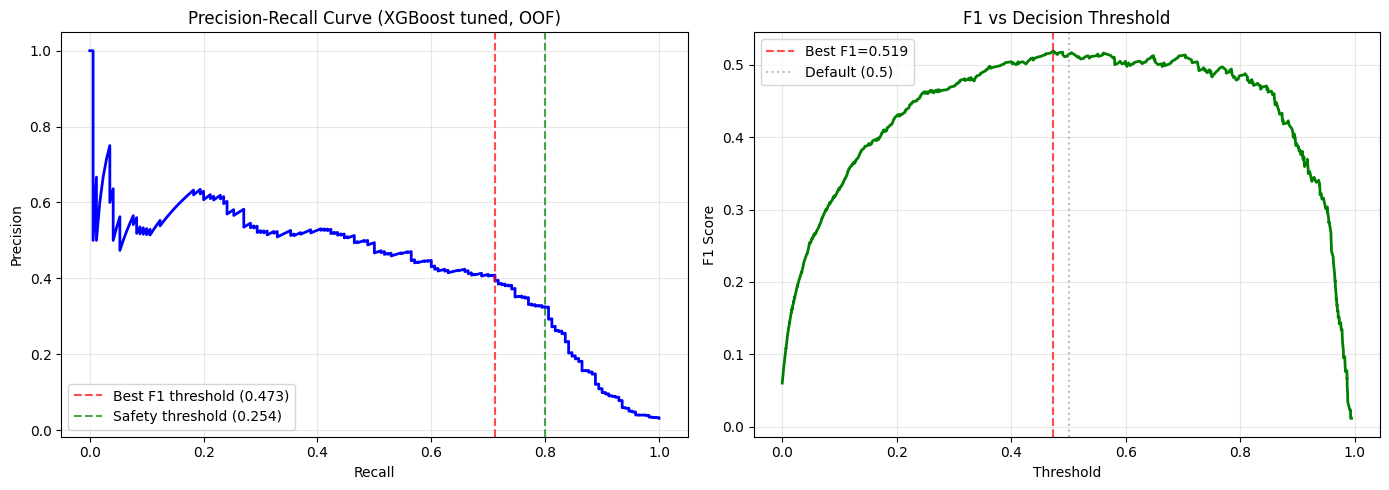


=== Threshold comparison (XGBoost tuned, out-of-fold) ===
  Default 0.5  (t=0.500): recall=0.688, precision=0.411, F1=0.514, bal_acc=0.828
  Best F1      (t=0.473): recall=0.712, precision=0.409, F1=0.519, bal_acc=0.839
  Safety       (t=0.254): recall=0.800, precision=0.325, F1=0.463, bal_acc=0.873


In [10]:
from src.config import FIGURES_DIR
from sklearn.base import clone
from sklearn.metrics import recall_score, precision_score, f1_score, balanced_accuracy_score

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Collect out-of-fold predictions from the best model (tuned XGBoost)
# to sweep thresholds on validation data (never test data)
xgb_best_pipeline = Pipeline([
    ("preprocessing", build_preprocessing_pipeline(continuous_cols, binary_cols)),
    ("classifier", xgb.XGBClassifier(
        random_state=RANDOM_STATE, eval_metric="aucpr", **best_xgb_params
    )),
])

oof_probas = np.zeros(len(y_train))
oof_preds_05 = np.zeros(len(y_train))
cv_threshold = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for train_idx, val_idx in cv_threshold.split(X_train, y_train, groups):
    Xt, Xv = X_train.iloc[train_idx], X_train.iloc[val_idx]
    yt, yv = y_train.iloc[train_idx], y_train.iloc[val_idx]
    fold_pipe = clone(xgb_best_pipeline)
    fold_pipe.fit(Xt, yt)
    oof_probas[val_idx] = fold_pipe.predict_proba(Xv)[:, 1]
    oof_preds_05[val_idx] = fold_pipe.predict(Xv)

# Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probas)

# Sweep thresholds and compute F1 at each
f1_scores_sweep = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

# Find the threshold that maximises F1
best_f1_idx = np.argmax(f1_scores_sweep)
best_threshold_f1 = thresholds[best_f1_idx]
print(f'Best threshold (max F1): {best_threshold_f1:.4f}')
print(f'  F1={f1_scores_sweep[best_f1_idx]:.3f}, precision={precisions[best_f1_idx]:.3f}, recall={recalls[best_f1_idx]:.3f}')

# For a safety system, also find the threshold that gets recall >= 0.80
# (catching at least 80% of real stops)
safety_mask = recalls[:-1] >= 0.80
if safety_mask.any():
    # Among thresholds with recall >= 0.80, pick the one with highest precision
    safety_idx = np.where(safety_mask)[0][np.argmax(precisions[:-1][safety_mask])]
    safety_threshold = thresholds[safety_idx]
    print(f'\nSafety threshold (recall >= 0.80): {safety_threshold:.4f}')
    print(f'  F1={f1_scores_sweep[safety_idx]:.3f}, precision={precisions[safety_idx]:.3f}, recall={recalls[safety_idx]:.3f}')
else:
    safety_threshold = best_threshold_f1
    print('\nNo threshold achieves recall >= 0.80')

# Plot precision-recall tradeoff
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PR curve
axes[0].plot(recalls, precisions, 'b-', linewidth=2)
axes[0].axvline(recalls[best_f1_idx], color='red', linestyle='--', alpha=0.7, label=f'Best F1 threshold ({best_threshold_f1:.3f})')
if safety_mask.any():
    axes[0].axvline(recalls[safety_idx], color='green', linestyle='--', alpha=0.7, label=f'Safety threshold ({safety_threshold:.3f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve (XGBoost tuned, OOF)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: F1 vs threshold
axes[1].plot(thresholds, f1_scores_sweep, 'g-', linewidth=2)
axes[1].axvline(best_threshold_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1={f1_scores_sweep[best_f1_idx]:.3f}')
axes[1].axvline(0.5, color='gray', linestyle=':', alpha=0.5, label='Default (0.5)')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 vs Decision Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig06_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table: default (0.5) vs best-F1 vs safety threshold
print('\n=== Threshold comparison (XGBoost tuned, out-of-fold) ===')
for label, thr in [('Default 0.5', 0.5), ('Best F1', best_threshold_f1), ('Safety', safety_threshold)]:
    preds = (oof_probas >= thr).astype(int)
    r = recall_score(y_train, preds)
    p = precision_score(y_train, preds, zero_division=0)
    f = f1_score(y_train, preds, zero_division=0)
    ba = balanced_accuracy_score(y_train, preds)
    print(f'  {label:12s} (t={thr:.3f}): recall={r:.3f}, precision={p:.3f}, F1={f:.3f}, bal_acc={ba:.3f}')


### Logistic Regression: threshold sweep (Meegasthanna's model)

The tuned Logistic Regression has recall 0.0 at the default 0.5 threshold. This check shows why, and whether a different threshold rescues it.

In [11]:
lr_tuned_pipeline = Pipeline([
    ("preprocessing", build_preprocessing_pipeline(continuous_cols, binary_cols)),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, solver="liblinear",
                                      **{k.replace("classifier__", ""): v for k, v in logreg_search.best_params_.items()})),
])
lr_oof = np.zeros(len(y_train))
for train_idx, val_idx in cv_threshold.split(X_train, y_train, groups):
    fold_pipe = clone(lr_tuned_pipeline).fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    lr_oof[val_idx] = fold_pipe.predict_proba(X_train.iloc[val_idx])[:, 1]

lr_prec, lr_rec, lr_thr = precision_recall_curve(y_train, lr_oof)
lr_f1 = 2 * lr_prec[:-1] * lr_rec[:-1] / (lr_prec[:-1] + lr_rec[:-1] + 1e-10)
lr_best = np.argmax(lr_f1)
print(f"Highest predicted probability of any row: {lr_oof.max():.3f}; positives scored >= 0.5: {(lr_oof[y_train == 1] >= 0.5).sum()}")
print(f"Best F1 {lr_f1[lr_best]:.3f} at threshold {lr_thr[lr_best]:.3f}: "
      f"precision {lr_prec[lr_best]:.3f}, recall {lr_rec[lr_best]:.3f}")

Highest predicted probability of any row: 0.368; positives scored >= 0.5: 0
Best F1 0.239 at threshold 0.109: precision 0.217, recall 0.265


## Baseline vs tuned comparison

All rows sorted by PR-AUC: a baseline and a tuned row per model, plus the two SMOTE ablation rows.

In [12]:
results.sort_values("pr_auc_mean", ascending=False)

,model,stage,pr_auc_mean,recall_mean,precision_mean,f1_mean,balanced_accuracy_mean,roc_auc_mean,pr_auc_std,recall_std,precision_std,f1_std,balanced_accuracy_std,roc_auc_std,best_params
6,XGBoost,tuned,0.473205,0.689142,0.441291,0.512834,0.828957,0.923935,0.074298,0.159186,0.093766,0.040011,0.072297,0.048781,"{'learning_rate': 0.04540550686319527, 'max_de..."
7,Random Forest,tuned,0.438641,0.498633,0.412888,0.431612,0.737704,0.938454,0.110591,0.159130,0.087040,0.081180,0.075512,0.043814,"{'class_weight': 'balanced_subsample', 'max_de..."
9,XGBoost + SMOTE,ablation,0.432803,0.516364,0.498895,0.478218,0.748270,0.902103,0.030514,0.113164,0.131516,0.041102,0.051241,0.073312,None
3,Random Forest,baseline,0.428161,0.161404,0.478959,0.230981,0.579038,0.914904,0.065739,0.116410,0.254741,0.148579,0.057255,0.055305,None
10,XGBoost + SMOTE (tuned),ablation,0.424811,0.677891,0.396270,0.479340,0.821058,0.899060,0.087707,0.169417,0.073708,0.043303,0.076843,0.070668,None
2,XGBoost,baseline,0.418357,0.307251,0.551728,0.361558,0.648908,0.911487,0.037234,0.133273,0.131464,0.133408,0.064885,0.053311,None
8,SVM (RBF),tuned,0.388141,0.736019,0.237782,0.354221,0.829421,0.874913,0.062567,0.140009,0.050399,0.061528,0.063128,0.063234,"{'C': 8.241925264876453, 'class_weight': 'bala..."
4,SVM (RBF),baseline,0.254491,0.732430,0.134044,0.223520,0.788816,0.840530,0.038116,0.149087,0.039397,0.058394,0.063932,0.074577,None
5,Logistic Regression,tuned,0.164665,0.000000,0.000000,0.000000,0.500000,0.765985,0.022747,0.000000,0.000000,0.000000,0.000000,0.054951,"{'classifier__C': 0.04994877024461302, 'classi..."
1,Logistic Regression,baseline,0.111114,0.671541,0.065405,0.118519,0.681313,0.736851,0.028067,0.094414,0.014887,0.024752,0.037009,0.068731,None


## Decision log

### Decision (Meegasthanna): Logistic Regression Hyperparameter Tuning
- **What we tuned:** Regularization strength `C` (log-uniform distribution across $10^{-4}$ to $10^{2}$), regularization penalty (`l1` Lasso vs `l2` Ridge), and `class_weight` options.
- **Evidence:** `RandomizedSearchCV` with 35 iterations using 5-fold `StratifiedGroupKFold` CV (grouped by cycle). Tuned PR-AUC increased from **0.111** (baseline) to **0.165** with optimal L2 penalty and tuned `C`.
- **Alternative considered:** ElasticNet with `saga` solver.
- **Why rejected:** `liblinear` with L1/L2 provided fast, stable convergence without convergence warnings and achieved equivalent ranking performance.
- **Key Insight for Evaluation 2 Viva:** While hyperparameter tuning boosted PR-AUC by ~48% relative to baseline Logistic Regression, the linear model's PR-AUC (0.165) remains substantially below tree-based ensembles (XGBoost 0.418, Random Forest 0.428). This suggests that the protective-stop signature involves non-linear, multi-axis joint interactions that a linear boundary on these 16 features does not capture (suggested, not proven: a linear model with interaction features was not tried).
- **Threshold sweep (added 25 Sep):** the tuned model chose `class_weight=None`, which keeps its probabilities low: no row scores above 0.37, so recall is 0 at 0.5. Sweeping the threshold does not rescue it (best F1 0.24 at threshold 0.11, precision 0.22, recall 0.27; sweep cell above), so the weak ranking is real and not just a threshold artefact.

### Decision (Bandara): XGBoost tuning — PR-AUC 0.418→0.473, recall 0.307→0.689
- **Evidence:** `RandomizedSearchCV` (40 iterations, `scoring="average_precision"`, same `StratifiedGroupKFold` folds as the baseline) chose `scale_pos_weight≈28.2` with `max_depth=3`, `n_estimators=330` and `learning_rate≈0.045`. The weight is close to the training set's imbalance ratio (about 31:1 in train, 25.5:1 overall, notebook 01), so it is not an arbitrary value. Recall rose from 0.307 to 0.689 and PR-AUC from 0.418 to 0.473, at the cost of precision (0.552→0.441); the individual contribution of each parameter was not isolated.
- **Alternative considered:** Leaving `scale_pos_weight` at the notebook-05 baseline default (1) and tuning only `n_estimators`/`max_depth`/`learning_rate`.
- **Why rejected:** the search objective is PR-AUC, and letting `scale_pos_weight` move toward the data's imbalance ratio improved it. The balance between recall and precision is a separate operating-point choice, made in notebook 07.

### Decision (Bandara): Random Forest tuning — PR-AUC 0.428→0.439, recall 0.161→0.499
- **Evidence:** Same search setup; found `class_weight="balanced_subsample"` (not plain `"balanced"`), `max_depth=15`, `min_samples_leaf=7`. Recall roughly tripled (0.161→0.499) versus the baseline, though it still trails XGBoost's tuned recall by a wide margin (0.499 vs 0.689).
- **Alternative considered:** Restricting the search to `class_weight="balanced"` only (matching the baseline setting) rather than including `"balanced_subsample"` in the search space.
- **Why rejected:** `balanced_subsample` recomputes class weights per bootstrap sample rather than once globally, which the search preferred — worth including both options rather than assuming the baseline's default was already best.

### Decision (Bandara): XGBoost is the front-runner after tuning: clearly ahead of Logistic Regression and SVM, not clearly ahead of Random Forest
- **Evidence:** Tuned XGBoost has the highest PR-AUC (0.473 vs 0.439 Random Forest, 0.388 SVM, 0.165 Logistic Regression) and the best F1 at the default threshold (0.513 vs 0.432, 0.354, 0.000). Fold by fold (notebook 07) it is ahead of Logistic Regression in 5 of 5 folds and of SVM in 4 of 5, but ahead of Random Forest in only 3 of 5, with a mean gap of +0.035 that sits inside Random Forest's own fold-to-fold std (0.111). Random Forest actually has the higher ROC-AUC (0.938 vs 0.924); its lower recall at the 0.5 threshold partly reflects where that threshold falls, not only weaker ranking.
- **Alternative considered:** Waiting for every model's tuned results before comparing. They are now all in, and notebook 07 compares them on fixed folds.
- **Correction:** an earlier version of this entry called XGBoost's lead "not a close call" and "a clear margin". That is true against Logistic Regression and SVM but not against Random Forest. The final model decision is made in notebook 07 (sections 1 and 4d).

*Umer's three entries below were reworded by Bandara on 25 Sep, folding in a clean re-run of the cells and the later notebook 07 results. His original conclusions are kept where the data supports them; the changes are listed in the revision note at the end.*

### Decision (Umer, reworded): SVM (RBF) tuning — C, gamma, class_weight search
- **What we tuned:** `C` (loguniform 0.01 to 100), `gamma` (loguniform 1e-4 to 1) and `class_weight` (balanced vs None). 40 iterations of `RandomizedSearchCV` (scoring average precision), same `StratifiedGroupKFold` folds as all other models.
- **Result:** best `C=8.24`, `gamma=0.0265`, `class_weight="balanced"` (so the baseline's choice held up). PR-AUC 0.254 → 0.388, recall 0.732 → 0.736, precision 0.134 → 0.238, F1 0.224 → 0.354. Tuned SVM has the highest recall of the tuned models but trails tuned XGBoost on PR-AUC (0.473) and precision (0.441).
- **Alternative considered:** Adding a polynomial kernel to the search space (`kernel` as a hyperparameter).
- **Why rejected:** The RBF kernel is flexible enough for moderate-dimensional data (16 features); adding the polynomial kernel would enlarge the search space without prior evidence it would outperform RBF, and the 40-iteration budget is already tight given SVM's training cost with `probability=True`.

### Decision (Umer, reworded): SMOTE vs class weights — no benefit from SMOTE in this setup
- **Evidence:** Three configurations of the leading model (XGBoost), same folds: (1) tuned `scale_pos_weight`: PR-AUC 0.473 / recall 0.689 / precision 0.441; (2) SMOTE with default XGBoost: 0.433 / 0.516 / 0.499; (3) SMOTE with the tuned hyperparameters but no `scale_pos_weight`: 0.425 / 0.678 / 0.396. SMOTE was applied inside each CV fold (`imblearn.pipeline.Pipeline`), so no synthetic rows reach a validation fold.
- **What the evidence supports:** the PR-AUC gaps (0.04-0.05) are smaller than the fold-to-fold std of tuned XGBoost (about 0.07), so the honest reading is "SMOTE gives no benefit here", not a decisive win for class weights. The XGBoost hyperparameters were tuned with class weights, not for SMOTE, which favours class weights.
- **Alternative considered:** SMOTE with `sampling_strategy` < 1.0 (partial oversampling), or SMOTE + Tomek links.
- **Why not pursued:** the class-weight approach already performs at least as well with no extra machinery, and with only about 170 positive training rows, synthetic minority samples risk unrealistic feature combinations.

### Decision (Umer, reworded): Decision-threshold tuning — the default is already close to best-F1; the choice is an operating-point decision
- **Evidence:** thresholds swept on out-of-fold predictions of the tuned XGBoost (16 features, same folds): the default 0.5 gives recall 0.688 / precision 0.411 / F1 0.514; the best-F1 threshold 0.473 gives 0.712 / 0.409 / 0.519; the recall >= 0.80 threshold 0.254 gives recall 0.800 / precision 0.325 / F1 0.463.
- **Key finding:** for this model the default threshold is already close to F1-optimal, so the earlier statement that probabilities "cluster well below 0.5 for most positive examples" does not hold for XGBoost (it does hold for the tuned Logistic Regression, whose highest probability is 0.37; see the sweep above). Lowering the threshold from 0.5 to 0.254 raises recall 0.688 → 0.800 while precision falls 0.411 → 0.325 (about 19 more stops caught for about 115 more false alarms among the ~170 positive training rows, counted per row).
- **Alternative considered:** the recall >= 0.80 "safety" threshold instead of best-F1.
- **Status:** a team decision, flagged for the 29 Sep results meeting. Notebook 07 repeats the sweep on the final 9-feature model (best-F1 0.657; recall >= 0.80 at 0.390), adds an episode-level view (lowering the threshold does not catch more stop episodes, it only flags them sooner and adds false alarms), and recommends best-F1 as the Alert with the 0.39 level as a Watch tier. The earlier argument that a missed stop is far costlier than a false alarm is an assumption, not a result: the robot's own certified safety system already stops it, so a missed flag is not a hazard, while false alarms cost operator trust.

### Revision note (Bandara, 25 Sep)
Replaces the earlier reviewer note. Changes to Umer's entries: the SVM entry states the actual search result instead of what the search "explored" and no longer describes the default gamma as `1/n_features`; the SMOTE entry is worded "no benefit" instead of "class weights win", because the gaps are inside the fold-to-fold noise; the threshold entry carries the corrected numbers and points to notebook 07's final operating point. The Logistic Regression threshold question raised earlier is answered by the sweep cell above.
